In [20]:
import math
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

from enum import Enum
from itertools import product
from scipy.signal import convolve2d

# some exercises depend on one another. but convolution is expensive and
# takes time. disable this to produce the data for dependant exercises,
# but skip expensive convolution
enable_convolution = True

# the path of the image to be analyzed
img_path = "profile_pic_2020_256x256.png"

# helper functions
def find_min_max(kernel):
    min = float("inf")
    max = float("-inf")

    for row in kernel:
        for v in row:
            if v < min:
                min = v
            if v > max:
                max = v

    return (min, max)

def make_gradient(kernel):
    min, max = find_min_max(kernel)

    if min <= 0 & 0 <= max:
        center = 0
    else:
        center = 0.5*(min+max)

    # - black for the center is ugly, but human vision is particularily good at
    #   discerning dark values. so black is the ideal color for the center.
    # - yellow and cyan are quite bright in comparison and have a high contrast
    #   to each other. "blue" vs yellow is favorable over red vs green, as red-
    #   green colorblindness is somewhat common, which i want to avoid
    neg = "#00ffff"
    ctr = "#000000"
    pos = "#ffff00"

    if max <= 0:
        gradient = [neg, ctr]
    elif min >= 0:
        gradient = [ctr, pos]
    else:
        gradient = [neg, ctr, pos]

    norm = mcolors.TwoSlopeNorm(vmin=min, vcenter=center, vmax=max)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_gradient",
        gradient
    )

    return (norm, cmap)


def plot_kernel(kernel):
    norm, cmap = make_gradient(kernel)
    plt.imshow(kernel, norm=norm, cmap=cmap)
    plt.colorbar()
    plt.show()

def apply_and_plot(kernel, img):
    if not enable_convolution:
        return

    kernel_ = normalize(kernel)
    img_ = normalize(img)

    out = convolve2d(img, kernel, mode='same')
    img_[:kernel_.shape[0], :kernel_.shape[1]] = kernel_

    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(img_, cmap="gray")
    axes[1].imshow(out, cmap="gray")
    plt.show()

def normalize(img):
    arr = np.array(img)
    normalized = (arr - arr.min()) / (arr.max() - arr.min())
    return normalized

(A)


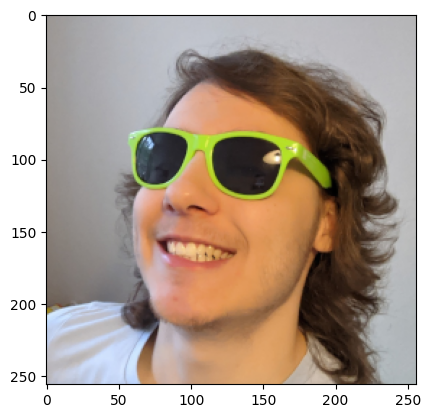

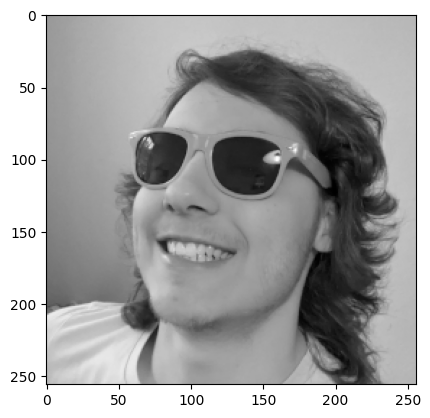

In [21]:
# Excercise 4. (A)
print("(A)")

img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

# prepare image
if img.ndim == 3:
    img = img.mean(axis=2)

plt.imshow(img, cmap="gray")
plt.show()

(B)
- L controls the width of the active field in the kernel
- v controls the weight of the surround field
- a positive v finds dark spots in the image
- a negative v finds bright spots in the image
- a wide kernel produces a blurry image
- a large L produces a double image



L: 30
v: 5


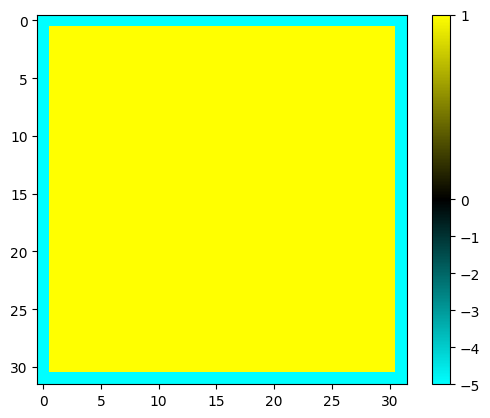

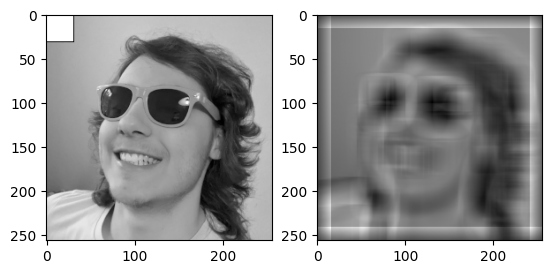

L: 16
v: 10


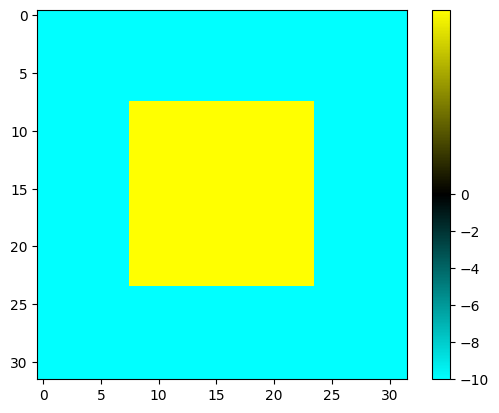

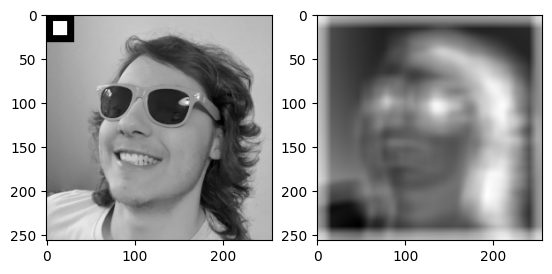

L: 16
v: -10


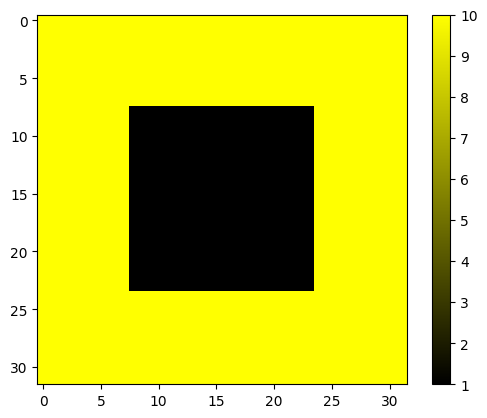

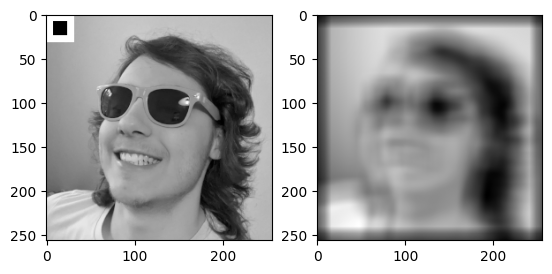

L: 2
v: 1


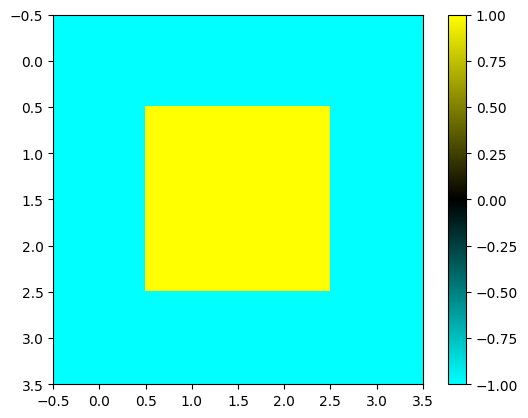

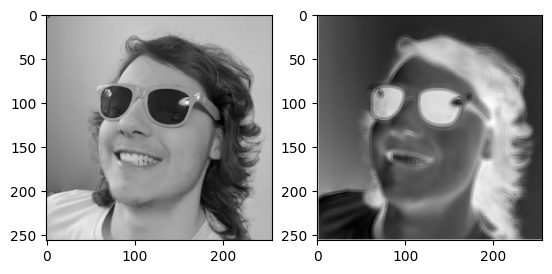

In [22]:
# Excercise 4. (B)
print("(B)")

# explanation
print("- L controls the width of the active field in the kernel")
print("- v controls the weight of the surround field")
print("- a positive v finds dark spots in the image")
print("- a negative v finds bright spots in the image")
print("- a wide kernel produces a blurry image")
print("- a large L produces a double image")

print()
print()
print()

# define helper class and function
class BoxParameter:
    def __init__(self, kernel_width, L, v):
        self.kernel_width = kernel_width
        self.L = L
        self.v = v

def make_box_kernel(kernel_width, L, v):
    kernel = np.ones((kernel_width,kernel_width)) * -v
    min = int((kernel_width - L) / 2)
    max = int((kernel_width + L) / 2)
    kernel[min:max, min:max] = 1
    return kernel

# define parameters
box_parameters = [
    BoxParameter(32, L=30, v=5),
    BoxParameter(32, L=16, v=10),
    BoxParameter(32, L=16, v=-10),
    BoxParameter(4, L=2, v=1),
]

# generate, apply kernel and plot resulting image
for p in box_parameters:
    kernel_width = p.kernel_width
    L = p.L
    v = p.v

    print(f"L: {L}")
    print(f"v: {v}")
    
    kernel = make_box_kernel(kernel_width, L, v)
    plot_kernel(kernel)
    apply_and_plot(kernel, img)

(C)
- sigma o controls the width of the gaussian
- w controls the weight of the gaussian
- c stands for center, and s for surround
- but it's easy to choose a sigma_c that is bigger than sigma_s, to produce an inhibiting receptive field
- a small gaussian filter detects details
- a large gaussian filter detects broader structures (ie it blurrs the image)
- depending on the sign of the gaussian, the receptive field may detect bright or dark spots



wc: 1.1
oc: 8
ws: 1
os: 24


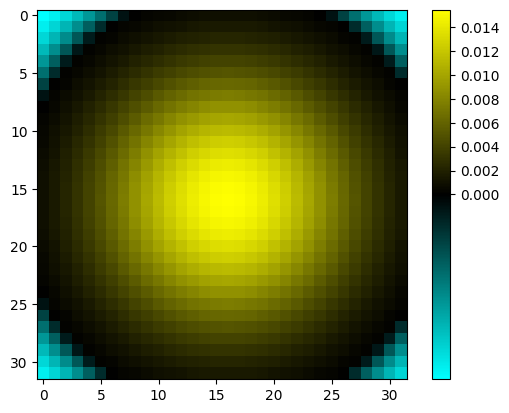

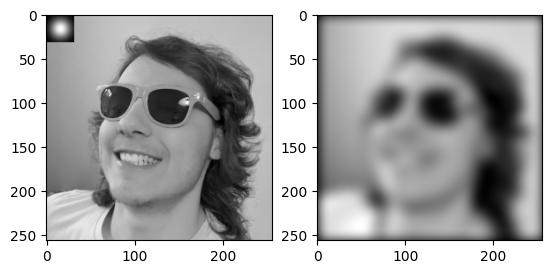

wc: 4.4
oc: 1.5
ws: 6.2
os: 5


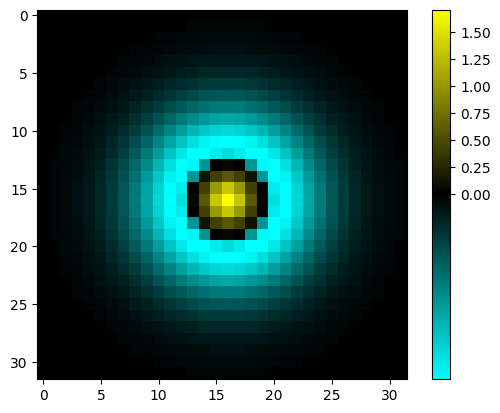

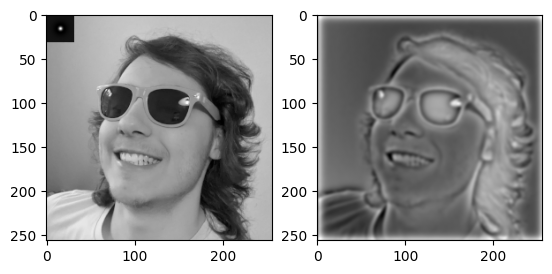

wc: 4.8
oc: 3
ws: 3.5
os: 1.8


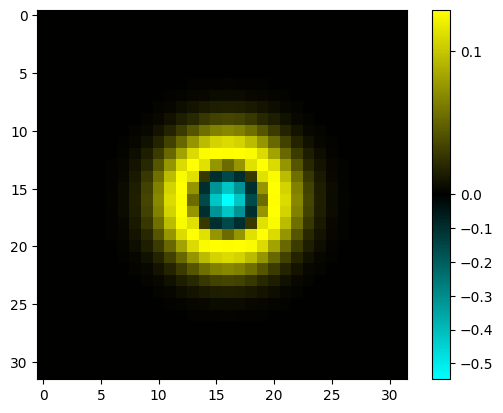

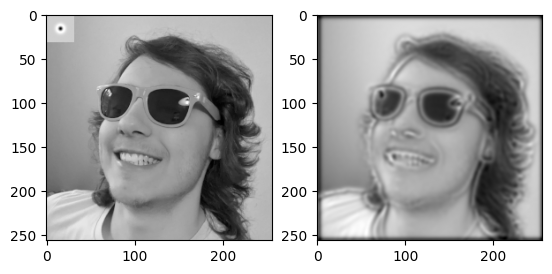

In [23]:
# Excercise 4. (C)
print("(C)")

# explanation
print("- sigma o controls the width of the gaussian")
print("- w controls the weight of the gaussian")
print("- c stands for center, and s for surround")
print("- but it's easy to choose a sigma_c that is bigger than sigma_s, to produce an inhibiting receptive field")
print("- a small gaussian filter detects details")
print("- a large gaussian filter detects broader structures (ie it blurrs the image)")
print("- depending on the sign of the gaussian, the receptive field may detect bright or dark spots")

print()
print()
print()

# define helper class and function
class GaussianParameter:
    def __init__(self, kernel_width, wc, oc, ws, os):
        self.kernel_width = kernel_width
        self.wc = wc
        self.oc = oc
        self.ws = ws
        self.os = os

# https://www.desmos.com/calculator/ytrkggiqib
def make_gaussian_kernel(p: GaussianParameter):
    kernel = np.zeros((p.kernel_width, p.kernel_width))

    for iy in range(p.kernel_width):
        for ix in range(p.kernel_width):
            x = ix - int(p.kernel_width / 2)
            y = iy - int(p.kernel_width / 2)

            x2 = x * x
            y2 = y * y
            x2y2 = x2 + y2
            wc = p.wc
            ws = p.ws
            oc = p.oc
            os = p.os
            oc2 = oc * oc
            os2 = os * os

            k1 = (wc / oc2) * math.exp(- x2y2 / (2 * oc2))
            k2 = (ws / os2) * math.exp(- x2y2 / (2 * os2))
            k = k1 - k2

            kernel[ix, iy] = k

    return kernel

# define parameters
N = 32
gaussian_parameters = [
    GaussianParameter(N, wc=1.1, oc=8, ws=1, os=24),
    GaussianParameter(N, wc=4.4, oc=1.5, ws=6.2, os=5),
    GaussianParameter(N, wc=4.8, oc=3, ws=3.5, os=1.8),
]

# generate, apply kernel and plot resulting image
for p in gaussian_parameters:
    print(f"wc: {p.wc}")
    print(f"oc: {p.oc}")
    print(f"ws: {p.ws}")
    print(f"os: {p.os}")
    
    kernel = make_gaussian_kernel(p)
    plot_kernel(kernel)
    apply_and_plot(kernel, img)

# explanation
# sigma o controls the width of the gaussian, omega w the weight or amplitude

(D) + (E)
- ox controls the width of the receptive field
- oy controls the height of the receptive field
- k is the frequency of the grating inside the receptive field and
- phi is the phase of the grating inside the receptive field
- the gabor filter detects edges and/or parallel lines
- the higher the frequency, the more parallel lines will be detected
- dependant on x and y, the gabor filter may select for horizontal or vertical edges and/or parallel lines



ox: 3.0
oy: 4.5
k: 0.39269908169872414
phi: 1.5707963267948966


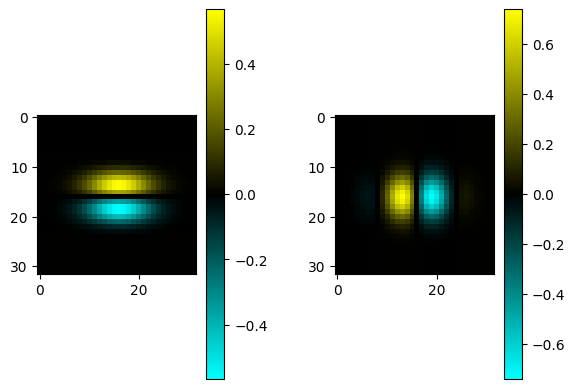

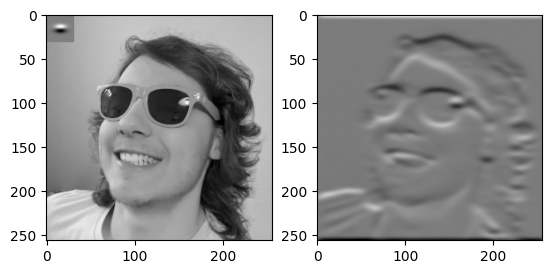

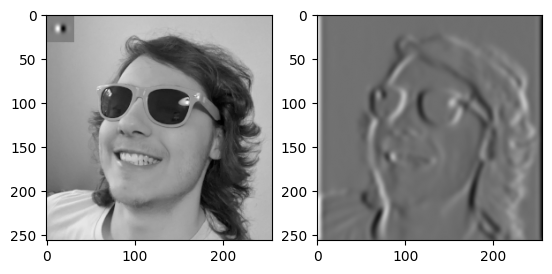

ox: 3.0
oy: 4.5
k: 0.7853981633974483
phi: 0


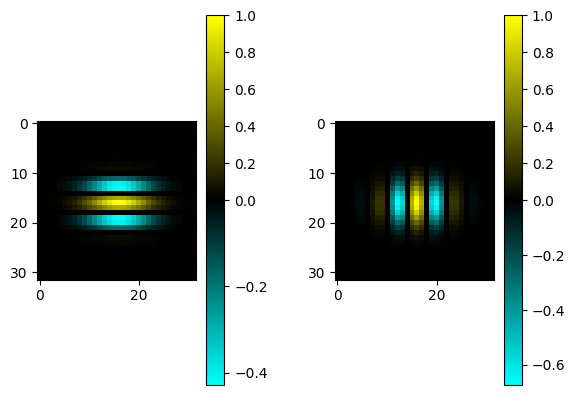

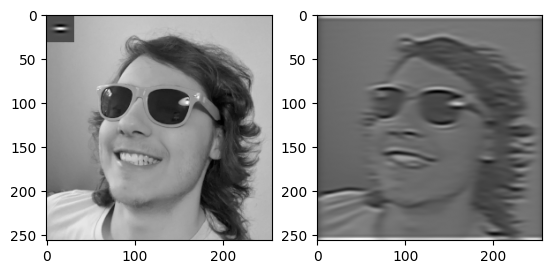

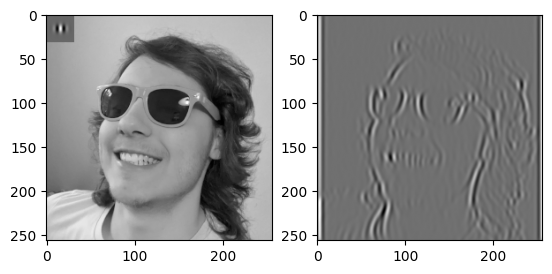

In [24]:
# Excercise 4. (D) + (E)
print("(D) + (E)")

# explanation
print("- ox controls the width of the receptive field")
print("- oy controls the height of the receptive field")
print("- k is the frequency of the grating inside the receptive field and")
print("- phi is the phase of the grating inside the receptive field")
print("- the gabor filter detects edges and/or parallel lines")
print("- the higher the frequency, the more parallel lines will be detected")
print("- dependant on x and y, the gabor filter may select for horizontal or vertical edges and/or parallel lines")

print()
print()
print()

# define helper class and function
class Orientation(Enum):
    HORIZONTAL = 1
    VERTICAL = 2

class GaborParameter:
    def __init__(
        self,
        kernel_width,
        ox,
        oy,
        k,
        phi,
    ):
        self.kernel_width = kernel_width
        self.ox = ox
        self.oy = oy
        self.k = k
        self.phi = phi

# https://www.desmos.com/calculator/qg2mdr2mqz
def make_gabor_kernel(p: GaborParameter, orientation):
    kernel = np.zeros((p.kernel_width, p.kernel_width))

    for iy in range(p.kernel_width):
        for ix in range(p.kernel_width):
            x = ix - int(p.kernel_width / 2)
            y = iy - int(p.kernel_width / 2)

            ox = p.ox
            oy = p.oy
            k = p.k
            phi = p.phi

            if orientation == Orientation.VERTICAL:
                val = x
            else:
                val = y
            
            exp = math.exp(-((x*x)/(2*ox*ox))-((y*y)/(2*oy*oy)))
            cos = math.cos(k * val + phi)
            k = exp * cos

            kernel[ix, iy] = k

    return kernel

# define parameters
N = 32
gabor_parameters = [
    GaborParameter(N, ox=3.0, oy=4.5, k=2 * 2 * math.pi / N, phi=math.pi/2),
    GaborParameter(N, ox=3.0, oy=4.5, k=4 * 2 * math.pi / N, phi=0),
]

# generate, apply kernel and plot resulting image
for p in gabor_parameters:
    print(f"ox: {p.ox}")
    print(f"oy: {p.oy}")
    print(f"k: {p.k}")
    print(f"phi: {p.phi}")
    
    kernel_vertical = make_gabor_kernel(p, Orientation.VERTICAL)
    kernel_horizontal = make_gabor_kernel(p, Orientation.HORIZONTAL)

    # plot kernel
    fig, axes = plt.subplots(1, 2)

    norm, cmap = make_gradient(kernel_vertical)
    im0 = axes[0].imshow(kernel_vertical, norm=norm, cmap=cmap)
    fig.colorbar(im0, ax=axes[0])

    norm, cmap = make_gradient(kernel_horizontal)
    im1 = axes[1].imshow(kernel_horizontal, norm=norm, cmap=cmap)
    fig.colorbar(im1, ax=axes[1])

    fig.subplots_adjust(wspace=0.5)

    plt.show()
    apply_and_plot(kernel_vertical, img)
    apply_and_plot(kernel_horizontal, img)

(F) + (G)
- g(k) is the contrast sensitivity function, which represents which wave/grating produces the greates neural response of a receptive field
=> this is equivalent to the furier transform
- k is close to k_hat, but it still differs. i suspect that's due to the finite nature of this kernel, producing slight artefacts





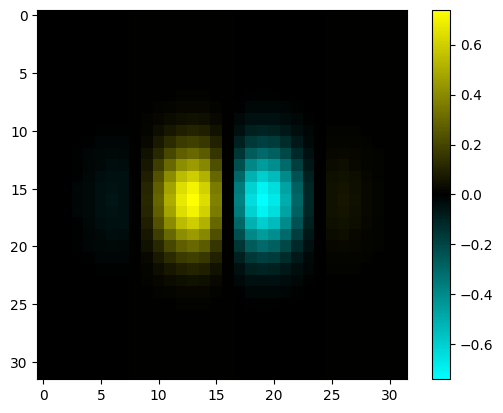

k_hat =     0.39269908169872414
k =         0.3943943943943944
k - k_hat = 0.001695312695670248


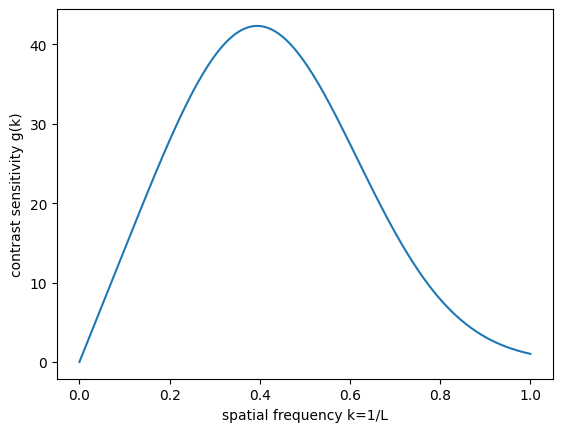

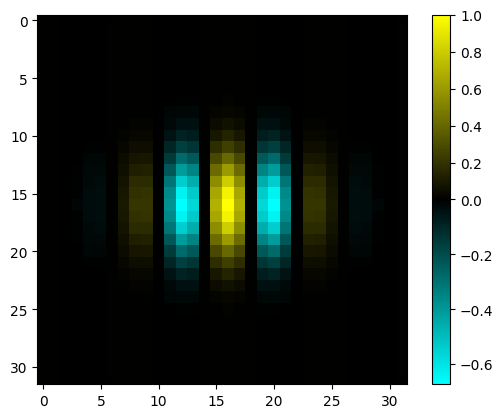

k_hat =     0.7853981633974483
k =         0.7857857857857857
k - k_hat = 0.00038762238833744966


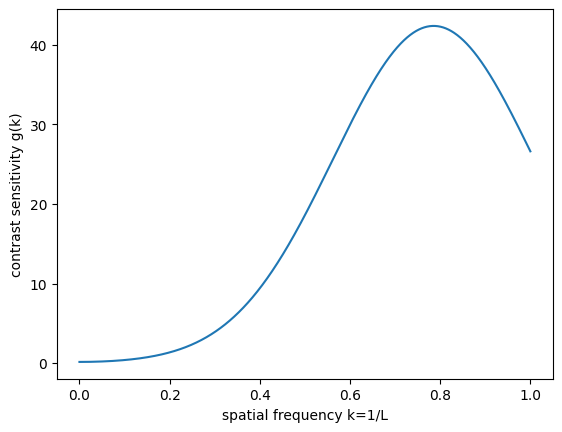

In [25]:
# Excercise 4. (F) + (G)
print("(F) + (G)")

# explanation
print("- g(k) is the contrast sensitivity function, which represents which wave/grating produces the greates neural response of a receptive field")
print("=> this is equivalent to the furier transform")
print("- k is close to k_hat, but it still differs. i suspect that's due to the finite nature of this kernel, producing slight artefacts")

print()
print()
print()

# define helper functions
def g_(kernel, k, callback):
    height, width = kernel.shape
    
    g = 0

    for iy in range(height):
        for ix in range(width):
            x = ix - int(width / 2)
            y = iy - int(height / 2)

            pixel = kernel[iy,ix]
            cos = callback(k * x)
            g += pixel * cos

    return g

def g_c(kernel, k):
    return g_(kernel, k, math.cos)

def g_s(kernel, k):
    return g_(kernel, k, math.sin)

def g(kernel, k):
    gs = g_s(kernel, k)
    gc = g_c(kernel, k)

    return math.sqrt(gs * gs + gc * gc)

# run contrast sensitivity function
for p in gabor_parameters:

    if not enable_convolution:
        break

    kernel = make_gabor_kernel(p, Orientation.HORIZONTAL)
    plot_kernel(kernel)
    
    x_values = np.linspace(0, 1, 1000)
    y_values = [g(kernel, x) for x in x_values]
    
    idx_max = np.argmax(y_values)
    k = x_values[idx_max]
    k_hat = p.k
    
    print(f"k_hat =     {p.k}")
    print(f"k =         {k}")
    print(f"k - k_hat = {k - k_hat}")
    
    plt.plot(x_values, y_values)
    plt.xlabel("spatial frequency k=1/L")
    plt.ylabel("contrast sensitivity g(k)")
    plt.show()

(H)
this is the furier transform





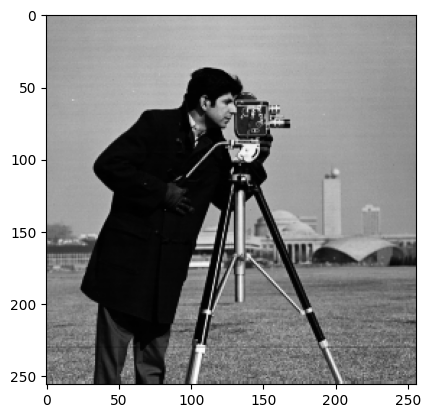

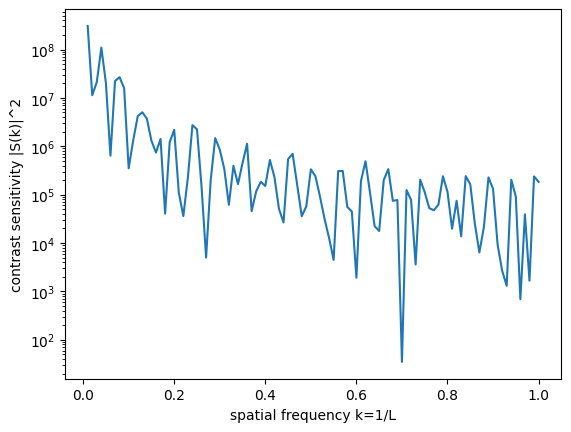

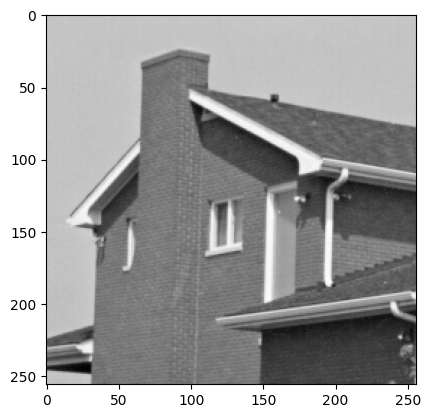

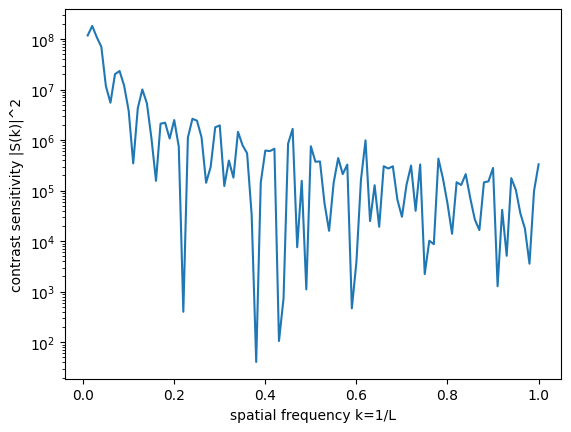

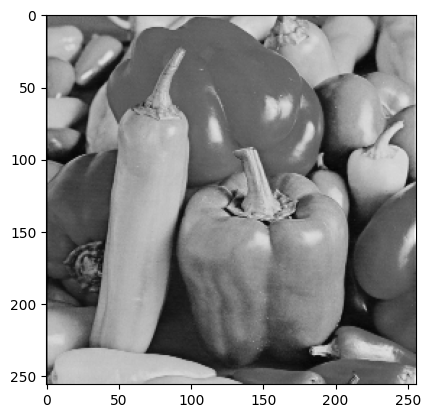

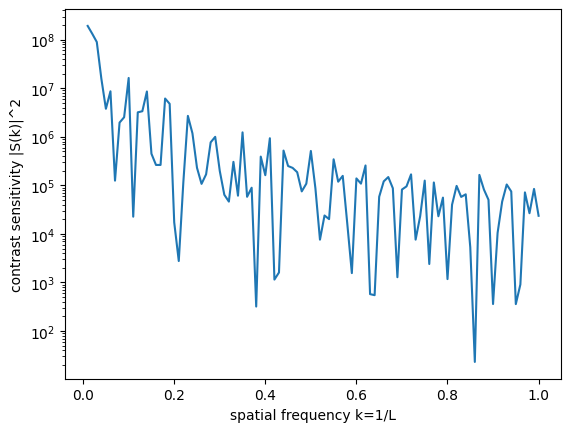

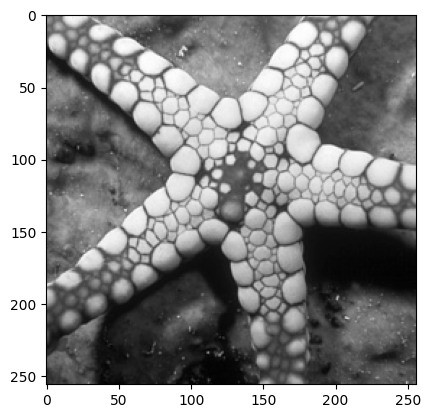

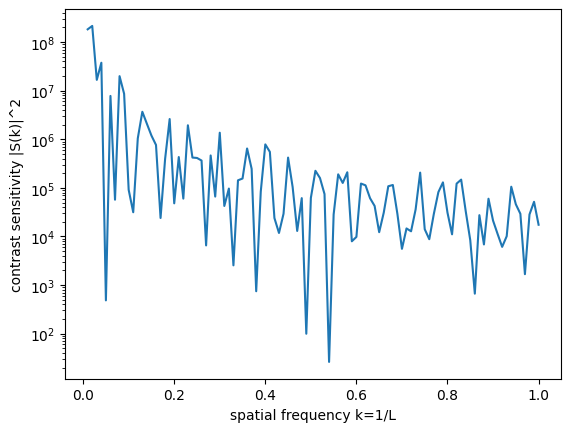

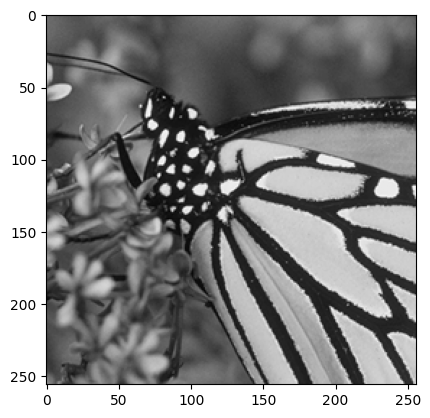

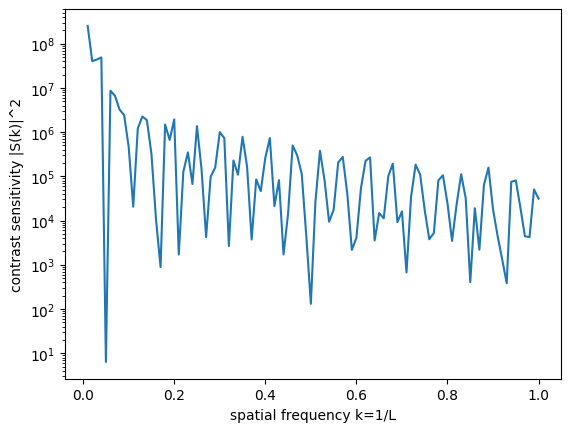

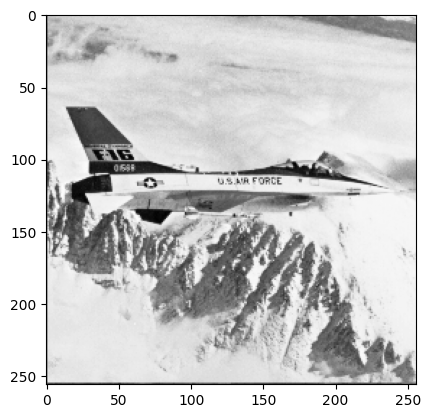

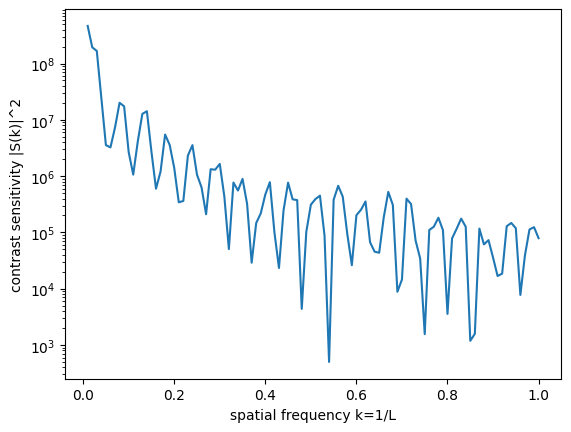

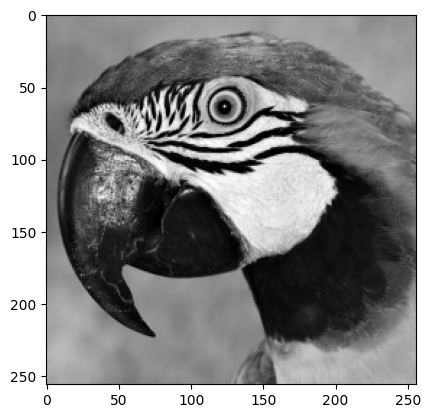

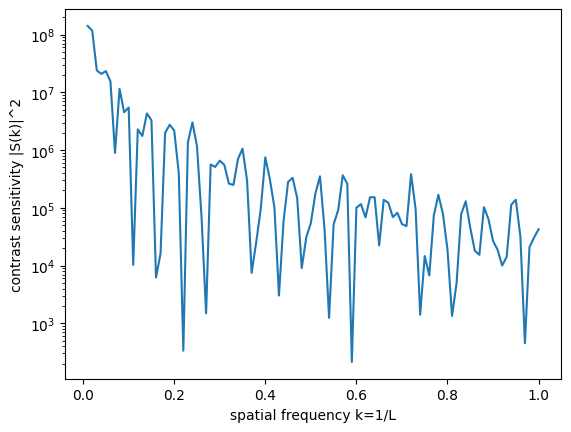

In [26]:
# Excercise 4. (H)
print("(H)")

# explanation
print("this is the furier transform")

print()
print()
print()

# define helper functions
def furier(kernel, k):
    gs = g_s(kernel, k)
    gc = g_c(kernel, k)

    return gs * gs + gc * gc

# get images
folder = Path("Set12/data/Set12.zip.decompressed/Set12/")
files = [
    "01.png",
    "02.png",
    "03.png",
    "04.png",
    "05.png",
    "06.png",
    "07.png",
]

images = []
for f in files:
    image = mpimg.imread(f)
    images.append(image)

# run contrast sensitivity function
for image in images:
    if not enable_convolution:
        break

    h = image.shape[0]
    w = image.shape[1]
    mirrored = np.zeros((h,w*2))
    for iy in range(mirrored.shape[0]):
        for ix in range(mirrored.shape[1]):
            if ix < w:
                mirrored[iy, ix] = image[iy, ix]
            else:
                mirrored[iy, ix] = image[iy, 2 * w - ix - 1]

    plt.imshow(image, cmap="gray")
    plt.show()
    
    max = 1
    resolution = 100
    x_values = np.linspace(0.01, max, resolution)
    y_values = [furier(mirrored, x) for x in x_values]

    plt.plot(x_values, y_values)
    plt.yscale("log")
    plt.xlabel("spatial frequency k=1/L")
    plt.ylabel("contrast sensitivity |S(k)|^2")
    plt.show()